# Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns

from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm

from statsmodels.tsa.holtwinters import ExponentialSmoothing



# Funções

In [2]:
def apresentar_estacionariedade(serie, log=True):
    resultado_adf = adfuller(serie)
    resultado_kpss = kpss(serie)
    estacionario = (resultado_adf[1] <= 0.05) and (resultado_kpss[1] > 0.05)
    if (log):
        print("="*40)
        print("Estatística ADF:", resultado_adf[0])
        print("p-valor ADF:", resultado_adf[1])
        print("p-valor KPSS:", resultado_kpss[1])
        print("É estacionário?", "Sim" if estacionario else "Não") # Se for menor igual a 0.05 significa que é estacionário
        print("Valores críticos:")
        for chave, valor in resultado_adf[4].items():
            print(f"    {chave}: {valor}")
    return estacionario
    

In [3]:
def tornar_estacionario(serie, target_column):
    diferenciacao = 0
    while not apresentar_estacionariedade(serie[target_column], False):
        diferenciacao += 1
        serie = serie.diff().dropna()
    
    return serie, diferenciacao

In [4]:
def analisar_series_temporais(df, coluna_data, figsize=(14, 5)):
    """
    Plota todas as colunas numéricas ao longo do tempo
    e gera uma matriz de correlação.

    Parameters
    ----------
    df : pandas.DataFrame
    coluna_data : str
        Nome da coluna de data.
    """

    if coluna_data not in df.columns:
        raise ValueError(f"Coluna '{coluna_data}' não encontrada.")

    # Cópia para evitar alterar o dataframe original
    df_plot = df.copy()

    # Conversão para datetime
    df_plot[coluna_data] = pd.to_datetime(df_plot[coluna_data])

    # Ordenação temporal
    df_plot = df_plot.sort_values(coluna_data)

    # Seleciona colunas numéricas
    colunas_numericas = df_plot.select_dtypes(include=np.number).columns

    # Plota cada série temporal
    for coluna in colunas_numericas:
        plt.figure(figsize=figsize)

        plt.plot(
            df_plot[coluna_data],
            df_plot[coluna]
        )

        plt.title(f"{coluna} ao longo do tempo")
        plt.xlabel(coluna_data)
        plt.ylabel(coluna)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Correlação
    correlacao = df_plot[colunas_numericas].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlacao,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title("Matriz de Correlação")
    plt.tight_layout()
    plt.show()

    return correlacao

In [5]:
def calcular_vif(df, colunas=None):
    """
    Calcula o Variance Inflation Factor (VIF) para as colunas informadas.

    Parameters
    ----------
    df : pandas.DataFrame
    colunas : list[str], optional
        Colunas a serem consideradas. Se None, utiliza todas as numéricas.

    Returns
    -------
    pandas.DataFrame
        DataFrame contendo Feature e VIF.
    """

    if colunas is None:
        colunas = df.select_dtypes(include=np.number).columns.tolist()

    X = df[colunas].copy()

    # Remove linhas com NaN
    X = X.dropna()

    vif_df = pd.DataFrame({
        "Feature": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

# Pegando dados

In [21]:
df_escalonado = pd.read_csv("data/base_escalonada.csv")
TARGET = "Close"
DATE_COLUMN = "Date"
colunas_numericas = df_escalonado.select_dtypes(
    include=np.number
).columns

deslocamento = (
    -df_escalonado[colunas_numericas].min().min()
    + 1e-6
)

df_escalonado[colunas_numericas] = (
    df_escalonado[colunas_numericas] + deslocamento
)

print(f"Deslocamento aplicado: {deslocamento:.6f}")
print(
    f"Menor valor após deslocamento: "
    f"{df_escalonado[colunas_numericas].min().min():.6f}"
)

Deslocamento aplicado: 7.485936
Menor valor após deslocamento: 0.000001


# Separar treino e teste e escalonando

In [22]:
# pensando em 3 dias para prever
h = int(len(df_escalonado) * 0.25)
train = df_escalonado[TARGET].iloc[:-h]

test  = df_escalonado[TARGET].iloc[-h:]


# Modelos

## Aditivo

In [23]:
hw_add = ExponentialSmoothing(
train, trend='add', seasonal='add', seasonal_periods=12, initialization_method='heuristic'
).fit()

print(f"AIC (Holt-Winters aditivo): {hw_add.aic:.2f}")
print(f"BIC (Holt-Winters aditivo): {hw_add.bic:.2f}")

AIC (Holt-Winters aditivo): -3897.95
BIC (Holt-Winters aditivo): -3805.44


## Multiplicativo

In [24]:
hw_mul = ExponentialSmoothing(
train, trend='add', seasonal='mul', seasonal_periods=12, initialization_method='heuristic'
).fit()

print(f"AIC (Holt-Winters multiplicativo): {hw_mul.aic:.2f}  |  aditivo: {hw_add.aic:.2f}")
print(f"BIC (Holt-Winters multiplicativo): {hw_mul.bic:.2f}  |  aditivo: {hw_add.bic:.2f}")

AIC (Holt-Winters multiplicativo): -3898.60  |  aditivo: -3897.95
BIC (Holt-Winters multiplicativo): -3806.09  |  aditivo: -3805.44


MAE Holt-Winters aditivo: 0.50
MAE Holt-Winters mult.: 0.50


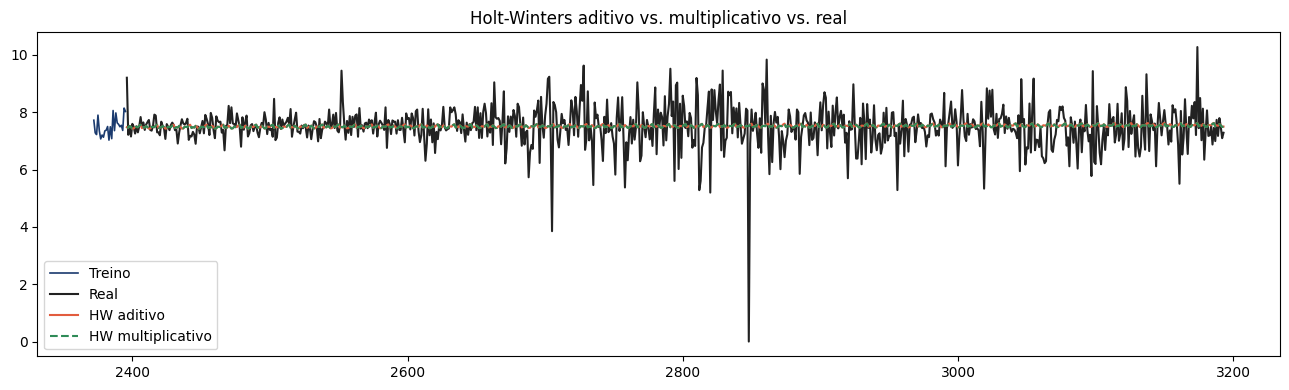

In [25]:
fc_add = hw_add.forecast(h)
fc_mul = hw_mul.forecast(h)

mae_add = mean_absolute_error(test, fc_add) 
mae_mul = mean_absolute_error(test, fc_mul) 

print(f"MAE Holt-Winters aditivo: {mae_add:.2f}")
print(f"MAE Holt-Winters mult.: {mae_mul:.2f}")

fig, ax = plt.subplots (figsize=(13, 4))
ax.plot(train[-24:].index, train [-24:], label='Treino', color='#1a3a6e', linewidth=1.2)
ax.plot(test.index, test, label='Real', color='#222', linewidth=1.5)
ax.plot(fc_add.index, fc_add, '', label='HW aditivo', color='#e25c3e', linewidth=1.5)
ax.plot(fc_mul.index, fc_mul, '--', label='HW multiplicativo', color='#2e8b57', linewidth=1.5)
ax.set_title('Holt-Winters aditivo vs. multiplicativo vs. real')
ax.legend()
plt.tight_layout()
plt.show()

## Análise dos parâmetros

Parâmetros estimados (Holt-Winters multiplicativo):
  smoothing_level      = 0.0160
  smoothing_trend      = 0.0063
  smoothing_seasonal   = 0.0231


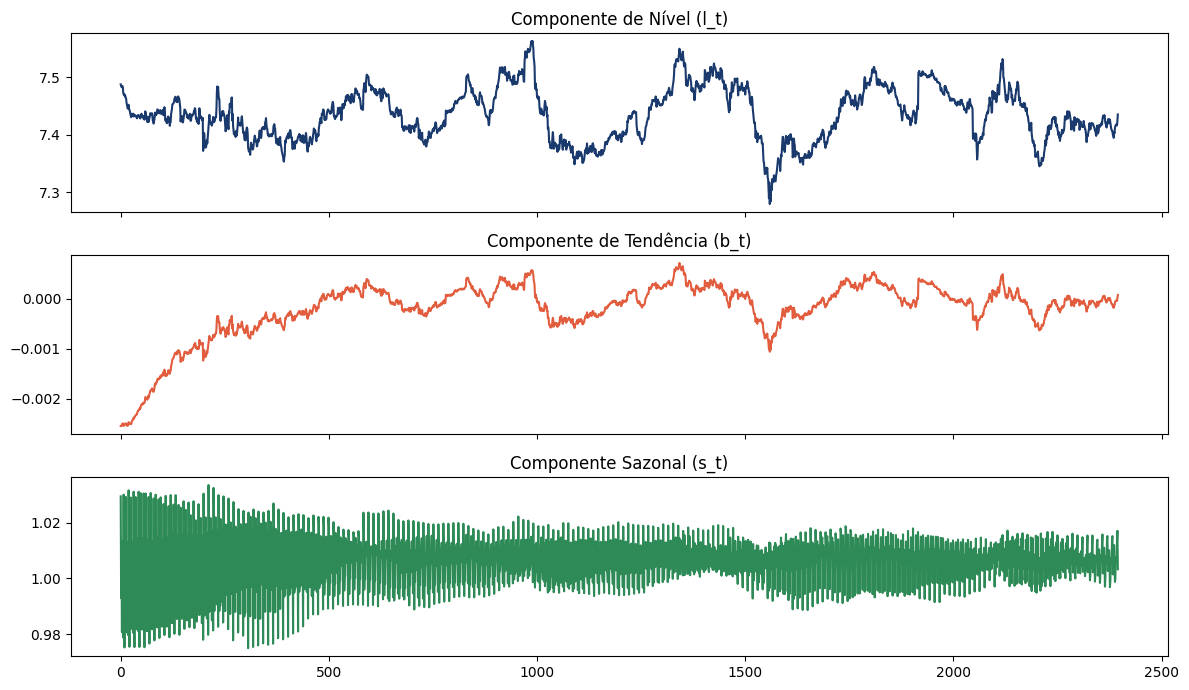

In [26]:
params = hw_mul.params
print("Parâmetros estimados (Holt-Winters multiplicativo):")
for nome in ["smoothing_level", "smoothing_trend", "smoothing_seasonal"]:
    print(f"  {nome:<20} = {params[nome]:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(train.index, hw_mul.level, color='#1a3a6e')
axes[0].set_title('Componente de Nível (l_t)')
axes[1].plot(train.index, hw_mul.trend, color='#e25c3e')
axes[1].set_title('Componente de Tendência (b_t)')
axes[2].plot(train.index, hw_mul.season, color='#2e8b57')
axes[2].set_title('Componente Sazonal (s_t)')
plt.tight_layout()
plt.show()

## Resíduo

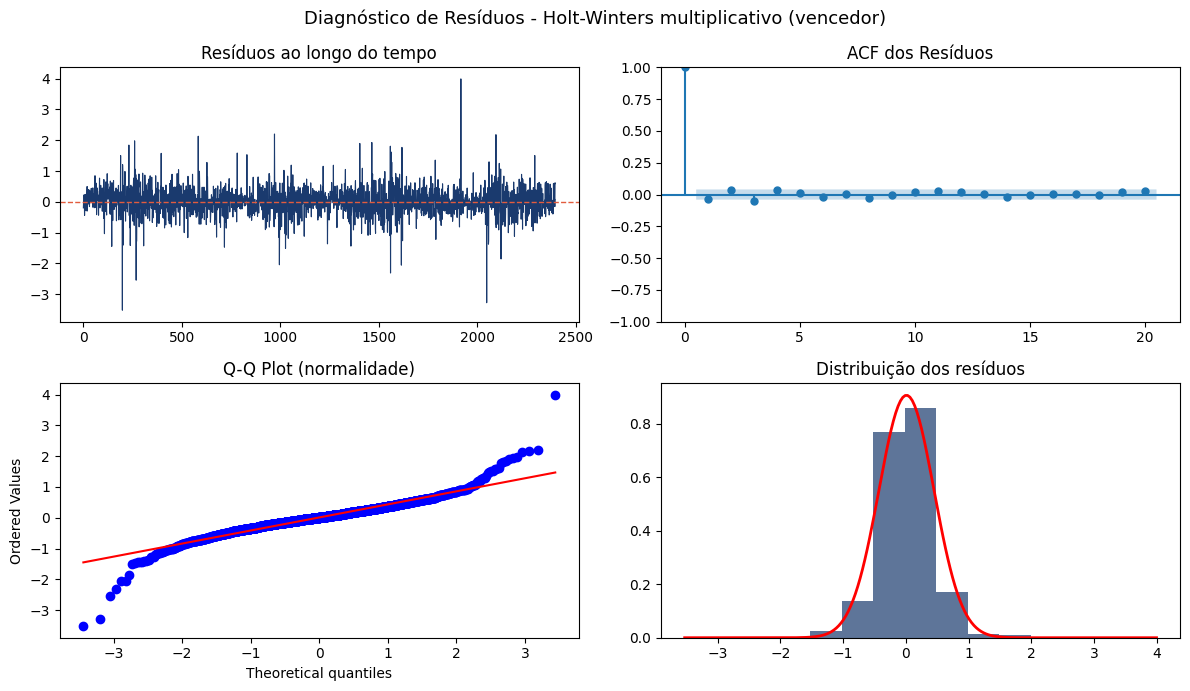

Ljung-Box (H0: resíduos sem autocorrelação):
    lb_stat  lb_pvalue
1    2.8676     0.0904
2    5.7501     0.0564
3   11.8506     0.0079
4   15.1836     0.0043
5   15.4937     0.0084
6   16.1156     0.0131
7   16.1923     0.0234
8   18.3515     0.0187
9   18.3559     0.0313
10  19.0943     0.0391
11  21.1744     0.0316
12  21.9177     0.0385


In [27]:
resid = hw_mul.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(resid.index, resid, color="#1a3a6e", linewidth=0.8)
axes[0, 0].axhline(0, color="#e25c3e", linewidth=1, linestyle="--")
axes[0, 0].set_title("Resíduos ao longo do tempo")

plot_acf(resid, lags=20, ax=axes[0, 1], title="ACF dos Resíduos")

stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot (normalidade)")

axes[1, 1].hist(resid, bins=15, density=True, color="#1a3a6e", alpha=0.7)
x = np.linspace(resid.min(), resid.max(), 200)
axes[1, 1].plot(x, norm.pdf(x, resid.mean(), resid.std()), "r-", linewidth=2)
axes[1, 1].set_title("Distribuição dos resíduos")

plt.suptitle("Diagnóstico de Resíduos - Holt-Winters multiplicativo (vencedor)", fontsize=13)
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=12, return_df=True)
print("Ljung-Box (H0: resíduos sem autocorrelação):")
print(lb[["lb_stat", "lb_pvalue"]].round(4))
todos_ok = (lb["lb_pvalue"] > 0.05).all()